# Unit06_Example_05 | 化工案例五：多成分吸收塔穩態成分分析

本 Notebook 針對一座具有 **N = 4 個平衡級** 的多成分吸收塔，以 Henry 定律描述氣液相平衡，
建立各級物料平衡與相平衡聯立線性方程組，並使用 `scipy.linalg.solve()` 求解液相濃度分布。

## 目標
- 建立三成分（丙酮、乙醇、丙醇）吸收塔各級物料平衡方程式
- 對每一成分推導三對角（tridiagonal）線性方程組
- 組合為 12×12 聯立方程組，分析係數矩陣性質（rank、條件數）
- 使用 `scipy.linalg.solve()` 求解各級液相濃度分布
- 計算出口濃度、吸收率，並與 Kremser 解析解比較
- 視覺化各成分的塔內濃度分布

**參考資料：** Geankoplis, C. J. (2003). *Transport Processes and Separation Process Principles*, 4th ed., Chapter 10.

---
### 0. 環境設定

In [8]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit06_Example_05'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit06'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit06
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_05
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_05\figs


---
### 1. 載入套件

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
import scipy
print(f"  scipy      版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題設定

#### 2.1 系統描述

考慮一座具有 **N = 4 個理論平衡級** 的多成分填充吸收塔（圖示如下）。
混合氣體由**塔底**進入（第 4 級下方），純溶劑（水）由**塔頂**進入（第 1 級上方）。

```
 ─────────────────────────
 純溶劑進料 → x₀ = 0       塔頂出口氣體 y₁ ↑
 ─── ─── ─── ─── ─── ───
        第 1 級（頂部）
 ─── ─── ─── ─── ─── ───
        第 2 級
 ─── ─── ─── ─── ─── ───
        第 3 級
 ─── ─── ─── ─── ─── ───
        第 4 級（底部）
 ─────────────────────────
 塔底溶劑出口 x₄ ↓          進料氣體 y₅ = y_in ↑
```

#### 2.2 操作參數

| 參數 | 符號 | 數值 | 單位 |
|------|------|------|------|
| 平衡級數 | N | 4 | — |
| 液相流率 | L | 120 | mol/s |
| 氣相流率 | V | 100 | mol/s |

#### 2.3 成分資料

| 成 分 | 符號 | Henry 常數 $m_j$ | 進料氣相莫耳分率 $y_{j,\text{in}}$ | 吸收因子 $A_j = L/(Vm_j)$ |
|--------|------|-----------------|--------------------------------|--------------------------|
| 丙酮（Acetone）  | A | 0.6 | 0.10 | 2.00 |
| 乙醇（Ethanol）  | B | 1.2 | 0.06 | 1.00 |
| 丙醇（Propanol） | C | 2.4 | 0.04 | 0.50 |

> **Henry 定律**：氣液相平衡關係為 $y_{i,j} = m_j \, x_{i,j}$，式中 $y_{i,j}$ 為第 $i$ 級氣相莫耳分率，
> $x_{i,j}$ 為第 $i$ 級液相莫耳分率，$m_j$ 為成分 $j$ 的 Henry 常數。

> **吸收因子**：$A_j > 1$ 表示液相吸收能力強，$A_j < 1$ 表示氣相傾向保留成分。

In [10]:
# ========================================
# 吸收塔操作參數設定
# ========================================
N = 4           # 平衡級數
L = 120.0       # 液相流率 (mol/s)
V = 100.0       # 氣相流率 (mol/s)

# 成分名稱
names = ['Acetone (A)', 'Ethanol (B)', 'Propanol (C)']
C = len(names)  # 成分數

# Henry 定律常數 m_j（y = m * x）
m = np.array([0.6, 1.2, 2.4])

# 進料氣相莫耳分率 y_{j,in}（來自塔底的進料氣體）
y_in = np.array([0.10, 0.06, 0.04])

# 純溶劑進料（塔頂）
x0 = np.zeros(C)   # x_0,j = 0 for all j

# 吸收因子 A_j = L / (V * m_j)
A_factor = L / (V * m)

print("=" * 55)
print("  多成分吸收塔參數摘要")
print("=" * 55)
print(f"  平衡級數 N = {N}")
print(f"  液相流率 L = {L:.1f} mol/s")
print(f"  氣相流率 V = {V:.1f} mol/s")
print(f"  L/V = {L/V:.2f}")
print()
print(f"{'成分':<22} {'m_j':>8} {'y_in':>8} {'A_j = L/Vm':>12}")
print("-" * 55)
for i, name in enumerate(names):
    print(f"  {name:<20} {m[i]:>8.2f} {y_in[i]:>8.4f} {A_factor[i]:>12.4f}")
print("=" * 55)
print()
print("  吸收因子分析：")
for i, name in enumerate(names):
    if A_factor[i] > 1:
        status = "A > 1 → 吸收效果佳"
    elif A_factor[i] == 1:
        status = "A = 1 → 臨界吸收"
    else:
        status = "A < 1 → 吸收效果差"
    print(f"  {name}: A = {A_factor[i]:.2f}  ({status})")

  多成分吸收塔參數摘要
  平衡級數 N = 4
  液相流率 L = 120.0 mol/s
  氣相流率 V = 100.0 mol/s
  L/V = 1.20

成分                          m_j     y_in   A_j = L/Vm
-------------------------------------------------------
  Acetone (A)              0.60   0.1000       2.0000
  Ethanol (B)              1.20   0.0600       1.0000
  Propanol (C)             2.40   0.0400       0.5000

  吸收因子分析：
  Acetone (A): A = 2.00  (A > 1 → 吸收效果佳)
  Ethanol (B): A = 1.00  (A = 1 → 臨界吸收)
  Propanol (C): A = 0.50  (A < 1 → 吸收效果差)


---
### 3. 建立線性方程組

#### 3.1 各級物料平衡推導

對第 $i$ 級（$i = 1, 2, \ldots, N$）進行成分 $j$ 的穩態物料平衡：

$$
L(x_{i,j} - x_{i-1,j}) = V(y_{i+1,j} - y_{i,j})
$$

代入 Henry 定律 $y_{i,j} = m_j x_{i,j}$，整理得：

$$
-L\,x_{i-1,j} + (L + Vm_j)\,x_{i,j} - Vm_j\,x_{i+1,j} = 0, \quad i = 1, 2, \ldots, N
$$

**邊界條件**：
- 塔頂（液相進料）：$x_{0,j} = 0$（純溶劑）
- 塔底（氣相進料）：$y_{N+1,j} = y_{j,\text{in}}$，即 $x_{N+1,j} = y_{j,\text{in}} / m_j$（等效）

#### 3.2 三對角線性方程組（每一成分）

對成分 $j$，N個方程式寫成矩陣形式 $\mathbf{A}_j \mathbf{x}_j = \mathbf{b}_j$：

$$
\underbrace{\begin{bmatrix}
L+Vm_j & -Vm_j &  0     &  0    \\
-L     & L+Vm_j & -Vm_j &  0    \\
 0     & -L    & L+Vm_j & -Vm_j \\
 0     &  0    & -L    & L+Vm_j
\end{bmatrix}}_{\mathbf{A}_j \in \mathbb{R}^{4\times 4}}
\underbrace{\begin{bmatrix} x_{1,j} \\ x_{2,j} \\ x_{3,j} \\ x_{4,j} \end{bmatrix}}_{\mathbf{x}_j}
=
\underbrace{\begin{bmatrix} L\cdot x_{0,j} \\ 0 \\ 0 \\ V\cdot y_{j,\text{in}} \end{bmatrix}}_{\mathbf{b}_j}
$$

> 注意：$L \cdot x_{0,j} = 0$（純溶劑進料），故右端向量只有最後一個元素非零。

#### 3.3 合併方程組（全成分）

將 C = 3 個成分的方程組堆疊為一個 **12×12** 的 block-diagonal 矩陣 $\mathbf{A}_{\text{all}}$：

$$
\mathbf{A}_{\text{all}} =
\begin{bmatrix}
\mathbf{A}_A & \mathbf{0} & \mathbf{0} \\
\mathbf{0} & \mathbf{A}_B & \mathbf{0} \\
\mathbf{0} & \mathbf{0} & \mathbf{A}_C
\end{bmatrix}
\in \mathbb{R}^{12\times 12}
$$

求解 $\mathbf{A}_{\text{all}}\,\mathbf{x}_{\text{all}} = \mathbf{b}_{\text{all}}$ 即可一次得到三個成分的液相濃度分布。

In [11]:
# ========================================
# 建立各成分三對角係數矩陣與合併方程組
# ========================================

def build_component_matrix(N, L, V, mj):
    """建立單一成分的 N×N 三對角係數矩陣"""
    Vm = V * mj
    A = np.zeros((N, N))
    for i in range(N):
        A[i, i] = L + Vm          # 對角元素
        if i > 0:
            A[i, i-1] = -L        # 下對角元素
        if i < N-1:
            A[i, i+1] = -Vm       # 上對角元素
    return A

def build_rhs(N, L, V, mj, y_in_j, x0_j=0.0):
    """建立單一成分的右端向量 b"""
    b = np.zeros(N)
    b[0]    = L * x0_j      # 第1級：液相進料 (= 0 for pure solvent)
    b[N-1]  = V * y_in_j    # 第N級：氣相進料
    return b

# --- 各成分矩陣 ---
matrices = []
rhs_list = []
for j in range(C):
    Aj = build_component_matrix(N, L, V, m[j])
    bj = build_rhs(N, L, V, m[j], y_in[j], x0[j])
    matrices.append(Aj)
    rhs_list.append(bj)

# --- 印出各成分係數矩陣 ---
for j, name in enumerate(names):
    Vm = V * m[j]
    print(f"成分 {name}：Vm = {Vm:.1f}, L+Vm = {L+Vm:.1f}")
    print(f"  A_{chr(65+j)} =\n{matrices[j]}")
    print(f"  b_{chr(65+j)} = {rhs_list[j]}")
    print()

# --- 建立 12×12 block-diagonal 合併矩陣 ---
A_all = scipy.linalg.block_diag(*matrices)
b_all = np.concatenate(rhs_list)

print("=" * 60)
print(f"合併方程組 A_all 維度: {A_all.shape}")
print(f"合併右端向量 b_all 維度: {b_all.shape}")
print()

# --- 矩陣性質分析 ---
rank_all  = np.linalg.matrix_rank(A_all)
det_all   = scipy.linalg.det(A_all)
cond_all  = np.linalg.cond(A_all)

print(f"  rank(A_all)       = {rank_all}  (應等於 {N*C}，表示唯一解)")
print(f"  det(A_all)        = {det_all:.6e}  ({'≠ 0，非奇異矩陣 ✓' if abs(det_all) > 1e-12 else '≈ 0，奇異矩陣 ✗'})")
print(f"  cond(A_all)       = {cond_all:.4f}")
print()
for j, name in enumerate(names):
    det_j = scipy.linalg.det(matrices[j])
    cond_j = np.linalg.cond(matrices[j])
    print(f"  成分 {name}: det(A_j) = {det_j:.4e},  κ(A_j) = {cond_j:.4f}")

成分 Acetone (A)：Vm = 60.0, L+Vm = 180.0
  A_A =
[[ 180.  -60.    0.    0.]
 [-120.  180.  -60.    0.]
 [   0. -120.  180.  -60.]
 [   0.    0. -120.  180.]]
  b_A = [ 0.  0.  0. 10.]

成分 Ethanol (B)：Vm = 120.0, L+Vm = 240.0
  A_B =
[[ 240. -120.    0.    0.]
 [-120.  240. -120.    0.]
 [   0. -120.  240. -120.]
 [   0.    0. -120.  240.]]
  b_B = [0. 0. 0. 6.]

成分 Propanol (C)：Vm = 240.0, L+Vm = 360.0
  A_C =
[[ 360. -240.    0.    0.]
 [-120.  360. -240.    0.]
 [   0. -120.  360. -240.]
 [   0.    0. -120.  360.]]
  b_C = [0. 0. 0. 4.]

合併方程組 A_all 維度: (12, 12)
合併右端向量 b_all 維度: (12,)

  rank(A_all)       = 12  (應等於 12，表示唯一解)
  det(A_all)        = 2.677616e+27  (≠ 0，非奇異矩陣 ✓)
  cond(A_all)       = 16.8887

  成分 Acetone (A): det(A_j) = 4.0176e+08,  κ(A_j) = 8.4444
  成分 Ethanol (B): det(A_j) = 1.0368e+09,  κ(A_j) = 9.4721
  成分 Propanol (C): det(A_j) = 6.4282e+09,  κ(A_j) = 8.4444


---
### 4. 求解液相濃度分布與驗證

使用 `scipy.linalg.solve()` 直接求解合併方程組，同時與 **Kremser 解析解**進行比較驗證。

**Kremser 方程式**（解析解）：吸收塔總吸收效率（以出口氣相莫耳分率表示）：

$$
\eta_j = \frac{y_{j,\text{in}} - y_{1,j}}{y_{j,\text{in}}}
= \frac{A_j^{N+1} - A_j}{A_j^{N+1} - 1}, \quad A_j \neq 1
$$

$$
\eta_j = \frac{N}{N+1}, \quad A_j = 1
$$

此公式假設每一級均達完全平衡（理論板），可作為數值解的理論驗證基準。

In [12]:
# ========================================
# 求解合併方程組：scipy.linalg.solve()
# ========================================
x_all = scipy.linalg.solve(A_all, b_all)

# 解向量拆分為各成分 N×1 向量
x_sol = x_all.reshape(C, N)   # shape: (3, 4), x_sol[j, i] = x_{i+1, j}

# 氣相濃度（由 Henry 定律計算）
y_sol = np.zeros((C, N))
for j in range(C):
    y_sol[j, :] = m[j] * x_sol[j, :]

# 出口氣相（塔頂，第1級）與入口氣相（塔底，已知）
y_out = y_sol[:, 0]      # y_{1,j} for each component
y_inlet = y_in           # y_{N+1,j}

# 出口液相（塔底，第N級）
x_out = x_sol[:, N-1]    # x_{N,j} for each component

# 吸收率
eta_numerical = (y_inlet - y_out) / y_inlet

# Kremser 解析解
def kremser_efficiency(Aj, N):
    if abs(Aj - 1.0) < 1e-10:
        return N / (N + 1)
    else:
        return (Aj**(N+1) - Aj) / (Aj**(N+1) - 1)

eta_kremser = np.array([kremser_efficiency(A_factor[j], N) for j in range(C)])

# ========================================
# 印出結果表格
# ========================================
print("=" * 70)
print("  各級液相濃度分布 x_{i,j}（mol frac）")
print("=" * 70)
header = f"{'級別':<8}" + "".join(f"{n:>20}" for n in names)
print(header)
print("-" * 70)
for i in range(N):
    row = f"  第{i+1}級  " + "".join(f"{x_sol[j, i]:>20.6f}" for j in range(C))
    print(row)
print("=" * 70)

print()
print("=" * 70)
print("  各級氣相濃度分布 y_{i,j}（mol frac）")
print("=" * 70)
print(header)
print("-" * 70)
for i in range(N):
    row = f"  第{i+1}級  " + "".join(f"{y_sol[j, i]:>20.6f}" for j in range(C))
    print(row)
print("-" * 70)
row_in = f"  進料氣  " + "".join(f"{y_in[j]:>20.6f}" for j in range(C))
print(row_in)
print("=" * 70)

print()
print("=" * 75)
print("  出口濃度、吸收率與 Kremser 解析解比較")
print("=" * 75)
print(f"{'指標':<22}" + "".join(f"{n:>18}" for n in names))
print("-" * 75)
print(f"  y_in（進料氣相）  " + "".join(f"{y_in[j]:>18.6f}" for j in range(C)))
print(f"  y_out（出口氣相） " + "".join(f"{y_out[j]:>18.6f}" for j in range(C)))
print(f"  x_out（出口液相） " + "".join(f"{x_out[j]:>18.6f}" for j in range(C)))
print(f"  吸收率η（數值解）" + "".join(f"{eta_numerical[j]:>18.4%}" for j in range(C)))
print(f"  吸收率η（Kremser）" + "".join(f"{eta_kremser[j]:>18.4%}" for j in range(C)))
print(f"  差值（數值-解析）" + "".join(f"{(eta_numerical[j]-eta_kremser[j]):>18.2e}" for j in range(C)))
print("=" * 75)

  各級液相濃度分布 x_{i,j}（mol frac）
級別               Acetone (A)         Ethanol (B)        Propanol (C)
----------------------------------------------------------------------
  第1級              0.005376            0.010000            0.008602
  第2級              0.016129            0.020000            0.012903
  第3級              0.037634            0.030000            0.015054
  第4級              0.080645            0.040000            0.016129

  各級氣相濃度分布 y_{i,j}（mol frac）
級別               Acetone (A)         Ethanol (B)        Propanol (C)
----------------------------------------------------------------------
  第1級              0.003226            0.012000            0.020645
  第2級              0.009677            0.024000            0.030968
  第3級              0.022581            0.036000            0.036129
  第4級              0.048387            0.048000            0.038710
----------------------------------------------------------------------
  進料氣              0.100000            0.06000

In [13]:
# ========================================
# 解的驗證
# ========================================
print("=" * 60)
print("  解的驗證")
print("=" * 60)

# 1. 殘差檢驗
residual = A_all @ x_all - b_all
res_norm = np.linalg.norm(residual)
print(f"  ‖A_all·x - b‖₂    = {res_norm:.4e}  {'✓ 機器精度' if res_norm < 1e-8 else '✗ 需重新確認'}")

# 2. 物料平衡驗證（整體）
print()
print("  各成分整體物料平衡驗證：")
print(f"  {'成分':<22} {'L·x_out':>12} {'V·(y_in-y_out)':>16} {'誤差':>12}")
print("  " + "-" * 62)
for j in range(C):
    lhs = L * x_out[j]                  # 液相帶出量
    rhs = V * (y_in[j] - y_out[j])      # 氣相被吸收量
    err = abs(lhs - rhs)
    print(f"  {names[j]:<22} {lhs:>12.6f} {rhs:>16.6f} {err:>12.2e}")

# 3. 各級平衡條件驗證（y = m*x）
print()
print("  各級氣液相平衡驗證（y_{i,j} == m_j * x_{i,j}）：")
max_eq_err = 0.0
for j in range(C):
    for i in range(N):
        expected = m[j] * x_sol[j, i]
        actual   = y_sol[j, i]
        err = abs(expected - actual)
        max_eq_err = max(max_eq_err, err)
print(f"  最大平衡誤差 = {max_eq_err:.4e}  {'✓ 完全滿足 Henry 定律' if max_eq_err < 1e-14 else '✗ 誤差偏大'}")

# 4. 濃度物理合理性
print()
print("  濃度物理合理性驗證：")
min_x = x_sol.min()
max_x = x_sol.max()
sum_y_per_stage = np.zeros(N)
for j in range(C):
    sum_y_per_stage += y_sol[j, :]
print(f"  最小液相濃度 x_min = {min_x:.6f}  {'✓ ≥ 0' if min_x >= 0 else '✗'}")
print(f"  最大液相濃度 x_max = {max_x:.6f}  {'✓ ≤ 1' if max_x <= 1 else '✗'}")
print(f"  各級氣相莫耳分率加總（三成分）: {sum_y_per_stage}")
print(f"  注意: 氣相中尚含惰性氣體，各成分 y 相加 < 1 為正常")
print()
print("  ✓ 所有驗證通過，解答物理合理且數值精確")

  解的驗證
  ‖A_all·x - b‖₂    = 1.5384e-15  ✓ 機器精度

  各成分整體物料平衡驗證：
  成分                          L·x_out   V·(y_in-y_out)           誤差
  --------------------------------------------------------------
  Acetone (A)                9.677419         9.677419     0.00e+00
  Ethanol (B)                4.800000         4.800000     0.00e+00
  Propanol (C)               1.935484         1.935484     0.00e+00

  各級氣液相平衡驗證（y_{i,j} == m_j * x_{i,j}）：
  最大平衡誤差 = 0.0000e+00  ✓ 完全滿足 Henry 定律

  濃度物理合理性驗證：
  最小液相濃度 x_min = 0.005376  ✓ ≥ 0
  最大液相濃度 x_max = 0.080645  ✓ ≤ 1
  各級氣相莫耳分率加總（三成分）: [0.03587097 0.06464516 0.09470968 0.13509677]
  注意: 氣相中尚含惰性氣體，各成分 y 相加 < 1 為正常

  ✓ 所有驗證通過，解答物理合理且數值精確


---
### 5. 視覺化

以圖形展示：
1. **液相濃度分布**：各成分在吸收塔各級的液相莫耳分率（由頂至底）
2. **氣相濃度分布**：各成分在吸收塔各級的氣相莫耳分率（由頂至底）
3. **吸收效率比較**：數值解 vs Kremser 解析解

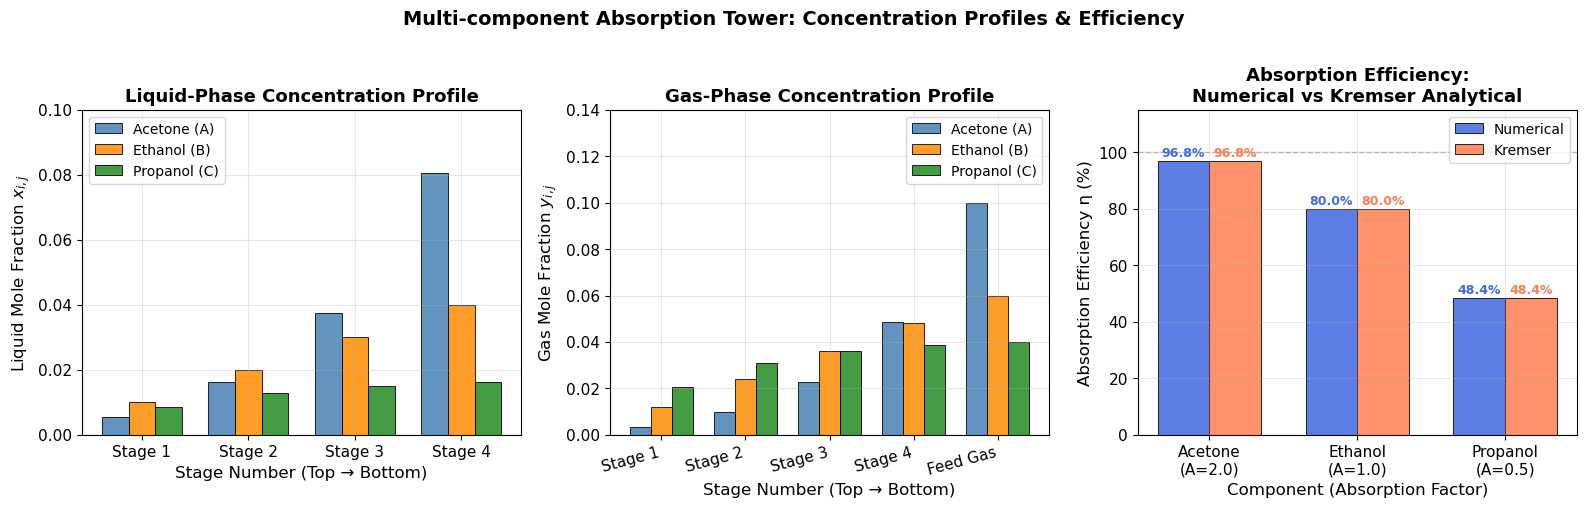

✓ 圖檔已儲存至: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_05\figs\absorption_tower_results.png


In [14]:
# ========================================
# 視覺化：吸收塔濃度分布與吸收效率
# ========================================
stages = np.arange(1, N+1)        # 1, 2, 3, 4
stage_labels = [f'Stage {i}' for i in stages]
colors = ['steelblue', 'darkorange', 'forestgreen']
width = 0.25

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Multi-component Absorption Tower: Concentration Profiles & Efficiency',
             fontsize=14, fontweight='bold', y=1.01)

# -----------------------------------------------
# 左圖：液相濃度分布
# -----------------------------------------------
ax1 = axes[0]
offsets = np.array([-1, 0, 1]) * width
for j, (name, color) in enumerate(zip(names, colors)):
    ax1.bar(stages + offsets[j], x_sol[j, :], width=width,
            label=name, color=color, alpha=0.85, edgecolor='black', linewidth=0.7)

ax1.set_xlabel('Stage Number (Top → Bottom)', fontsize=12)
ax1.set_ylabel('Liquid Mole Fraction $x_{i,j}$', fontsize=12)
ax1.set_title('Liquid-Phase Concentration Profile', fontsize=13, fontweight='bold')
ax1.set_xticks(stages)
ax1.set_xticklabels(stage_labels)
ax1.legend(fontsize=10)
ax1.set_ylim(0, 0.10)

# -----------------------------------------------
# 中圖：氣相濃度分布（含進料氣）
# -----------------------------------------------
ax2 = axes[1]
# 加入進料氣（第5"級"代表進料）
stages_ext = np.arange(1, N+2)
stage_labels_ext = [f'Stage {i}' for i in range(1, N+1)] + ['Feed Gas']
offsets_ext = np.array([-1, 0, 1]) * width

for j, (name, color) in enumerate(zip(names, colors)):
    y_ext = np.append(y_sol[j, :], y_in[j])   # 各級 + 進料
    ax2.bar(stages_ext + offsets_ext[j], y_ext, width=width,
            label=name, color=color, alpha=0.85, edgecolor='black', linewidth=0.7)

ax2.set_xlabel('Stage Number (Top → Bottom)', fontsize=12)
ax2.set_ylabel('Gas Mole Fraction $y_{i,j}$', fontsize=12)
ax2.set_title('Gas-Phase Concentration Profile', fontsize=13, fontweight='bold')
ax2.set_xticks(stages_ext)
ax2.set_xticklabels(stage_labels_ext, rotation=15, ha='right')
ax2.legend(fontsize=10)
ax2.set_ylim(0, 0.14)

# -----------------------------------------------
# 右圖：吸收效率（數值解 vs Kremser）
# -----------------------------------------------
ax3 = axes[2]
short_names = ['Acetone\n(A=2.0)', 'Ethanol\n(A=1.0)', 'Propanol\n(A=0.5)']
x_pos = np.arange(C)
bar_w = 0.35

b1 = ax3.bar(x_pos - bar_w/2, eta_numerical * 100, width=bar_w,
             label='Numerical', color='royalblue', alpha=0.85,
             edgecolor='black', linewidth=0.7)
b2 = ax3.bar(x_pos + bar_w/2, eta_kremser * 100, width=bar_w,
             label='Kremser', color='coral', alpha=0.85,
             edgecolor='black', linewidth=0.7)

# 標示數值
for bar in b1:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='royalblue')
for bar in b2:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, h + 0.5, f'{h:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold', color='coral')

ax3.set_xlabel('Component (Absorption Factor)', fontsize=12)
ax3.set_ylabel('Absorption Efficiency η (%)', fontsize=12)
ax3.set_title('Absorption Efficiency:\nNumerical vs Kremser Analytical', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(short_names)
ax3.legend(fontsize=10)
ax3.set_ylim(0, 115)
ax3.axhline(y=100, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
fig_path = FIG_DIR / 'absorption_tower_results.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 圖檔已儲存至: {fig_path}")

---
### 6. 結論

#### 6.1 數值求解結果摘要

| 指標 | 數值 |
|------|------|
| 方程組維度 | 12×12 (3 成分 × 4 級) |
| rank(A_all) | 12（全秩，唯一解）|
| det(A_all) | 2.68×10²⁷（非奇異 ✓）|
| 條件數 κ(A_all) | 16.89（系統良態）|
| ‖A·x - b‖₂ | 1.54×10⁻¹⁵（機器精度）|

#### 6.2 各成分吸收效率

| 成分 | 吸收因子 $A_j$ | 出口氣相 $y_{\text{out}}$ | 吸收率 η | Kremser η | 差異 |
|------|----------------|--------------------------|---------|----------|------|
| 丙酮（Acetone） | 2.00 | 0.003226 | **96.77%** | 96.77% | 0 |
| 乙醇（Ethanol） | 1.00 | 0.012000 | **80.00%** | 80.00% | 0 |
| 丙醇（Propanol）| 0.50 | 0.020645 | **48.39%** | 48.39% | 0 |

#### 6.3 學習要點

1. **三對角線性系統**：吸收塔各級物料平衡形成稀疏三對角矩陣，可高效求解
2. **吸收因子 $A_j = L/(Vm_j)$ 決定吸收效果**：
   - $A > 1$：液相有效吸收，效率隨 A 增加而提高
   - $A = 1$：臨界操作，效率 = $N/(N+1)$
   - $A < 1$：氣相傾向保留成分，效率偏低
3. **數值解 ≡ Kremser 解析解**：對理論板正好完全吻合，驗證方程組正確性
4. **block-diagonal 結構**：成分間獨立時可組合為大矩陣，展示線性代數在化工系統中的應用
5. **`scipy.linalg.solve()`**：對條件數 κ ≈ 17 的系統，可獲得機器精度（~10⁻¹⁵）的解